# ch05 이산형 확률분포

- 1차원 이산형 확률변수

In [77]:
import numpy as np
import matplotlib.pyplot as plt

%precision 3
%matplotlib inline

In [78]:
#아래는 한글을 사용할 때 깨지는 문제에 대한 해결
from matplotlib import font_manager, rc
font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family=font_name)

#그래프의 축 등에서 음수를 표시할 때 minus sign이 깨지는 것 해결
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False

    - 확률변수 X가 취할 수 있는 값의 집합 : {x1, x2, .....}
    - X가 xk라는 값을 취하는 확률 : P(X = xk) = pk (k = 1, 2, ....)
    - 확률(질량)함수 : f(x) = P(X = x)

In [79]:
#확률변수가 취할 수 있는 값의 집합
x_set = np.array([1, 2, 3, 4, 5, 6])

In [80]:
def f(x):
    if x in x_set:
        return x / 21
    else:
        return 0
    
X = [x_set, f]

In [81]:
# 확률 p_k를 구한다
prob = np.array([f(x_k) for x_k in x_set])
# x_k와 p_k의 대응을 사전식으로 표시
dict(zip(x_set, prob))

{np.int64(1): 0.048,
 np.int64(2): 0.095,
 np.int64(3): 0.143,
 np.int64(4): 0.190,
 np.int64(5): 0.238,
 np.int64(6): 0.286}

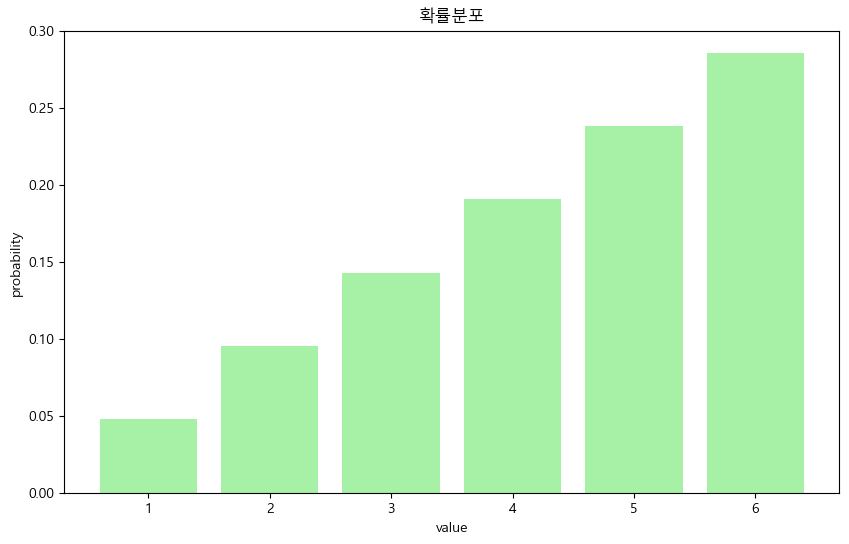

In [82]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.bar(x_set, prob, color = 'lightgreen', alpha = 0.8)
ax.set_xlabel('value')
ax.set_ylabel('probability')
ax.set_title('확률분포')
plt.show()

In [83]:
#  .get() : () 안의 '키'에 해당하는 '밸류' 가져오기
딕예 = {'사과': 1, '딸기': 2, '귤': 3}
예 = 딕예.get('딸기')
예

2

In [84]:
#확률의 성질 : f(xk) >= 0, sigma k~ f(xk) = 1(f(xk)의 확률 총 합계는 1(0~1 사잇값))
np.all(prob >= 0) #np.all은 모든 요소가 '참'일 때만 '참' 반환

np.True_

In [85]:
np.sum(prob)

1.000

In [86]:
#(누적)분포함수 : X가 x이하가 될 때의 확률을 반환
def F(x):
    return np.sum([f(x_k) for x_k in x_set if x_k <= x])
F(3)

0.286

In [87]:
#확률변수의 변환
# - 확률변수 X에 *2 + 3 한 2X + 3도 확률변수
# - 2X + 3을 확률변수 Y라 하면 -> Y의 확률분포
y_set = np.array([2 * x_k + 3 for x_k in x_set])
prob = np.array([f(x_k) for x_k in x_set])
dict(zip(y_set, prob))

{np.int64(5): 0.048,
 np.int64(7): 0.095,
 np.int64(9): 0.143,
 np.int64(11): 0.190,
 np.int64(13): 0.238,
 np.int64(15): 0.286}

In [88]:
# 기댓값 E(X)
# = 확률변수의 평균
# - 확률변수를 몇 번(무제한) 시행해 얻은 실현값의 평균
# - 무제한으로 실행할 수는 없으므로 E(X) = sigma (확률변수가 취할 수 있는 값 * 확률)
np.sum([x_k * f(x_k) for x_k in x_set])

4.333

In [89]:
#예>
sample = np.random.choice(x_set, int(1e6), p=prob)
np.mean(sample)

4.332

In [90]:
#참고> 데이터 샘플링
# - 이미 있는 데이터 집합에서 일부를 무작위로 선택
# - choice() 사용

#np.random.choice(a, size = None, replace = True p = None) 형태
                 #a : 배열 형태. 배열 그대로 들어오면 원래의 데이터를, 정수로 들어오면 arange(a)한 것을 넣음
                 #size : 샘플 수
                 #replace : boolean, True면 데이터 꺼내고 다시 넣으므로 같은 데이터 뽑기 가능(조합 nCr)
                 #                   False면 다시 꺼내기 불가(순열 nPr)
                 #p : 배열. 각 데이터가 선택될 확률

np.random.choice(5, 5, replace = False)
np.random.choice(5, 10)
np.random.choice(5, 10, p = [0.1, 0, 0.3, 0.6, 0]) #선택될 확률 다르게 10개 선택

array([3, 3, 3, 3, 3, 3, 2, 3, 0, 3], dtype=int32)

In [91]:
# 기댓값 E(X)
# = 확률변수의 평균
# - 수식을 기댓값의 함수로 구현
# - 인수 g가 확률변수에 대한 변환 함수
def E(X, g=lambda x: x):  #g에 지정 안하면 확률변수 X의 기댓값 구해짐
    x_set, f = X
    return np.sum([g(x_k) * f(x_k) for x_k in x_set])

E(X)

4.333

In [92]:
#확률변수 Y = 2X + 3의 기댓값
E(X, g=lambda x: 2*x + 3)

11.667

In [93]:
#기댓값의 선형성
# : E(aX + b) = aE(X) + b로 표현 가능
2 * E(X) + 3

11.667

In [94]:
#참고> 람다 함수(익명 함수)
# - 리스트의 sort 메서드에 람다 함수 넘겨 정렬 가능
strex = ['hyeja', 'parkhyeja', 'youngtae', 'kimyoungtae', 'bbangtae']
strex.sort(key = lambda x: len(set(list(x)))) #조건: 글자 길이 > 알파벳 순
strex

['hyeja', 'bbangtae', 'parkhyeja', 'youngtae', 'kimyoungtae']

In [95]:
#분산
mean = E(X)
np.sum([(x_k-mean)**2 * f(x_k) for x_k in x_set])

2.222

In [96]:
#이산형 확률변수의 분산
def V(X, g=lambda x: x):
    x_set, f = X
    mean = E(X, g)
    return np.sum([(g(x_k)-mean)**2 * f(x_k) for x_k in x_set])

V(X)

2.222

In [32]:
#확률변수 Y = 2X + 3의 분산
V(X, lambda x: 2*x + 3)

8.889

In [33]:
#분산의 공식 : a, b를 실수, X를 확률변수라고 하면 V(aX + b) = a**2 * V(X)
#예> V(2X + 3) = 2**2 * V(X) = 4V(X)
2**2 * V(X)

8.889

- 2차원 이산형 확률변수

    # 결합확률분포 : 확률변수 X가 xi, 확률변수 Y가 yj 취할 확률
    # - 1차원 확률분포 2개를 동시에 다룸
    # - P(X = xi, Y = yj) = pij (i = 1, 2, .....; j = 1, 2, .....)
    # - 확률변수 (X, Y)의 움직임 동시에 고려
    # 결합확률함수 : P(X = x, Y = y) = fxy(x, y)

In [34]:
#확률의 성질 : X와 Y가 취할 수 있는 값의 집합
x_set = np.arange(2, 13)
y_set = np.arange(1, 7)

In [35]:
#결합확률함수
def f_XY(x, y):
    if 1 <= y <=6 and 1 <= x - y <= 6:
        return y * (x-y) / 441
    else:
        return 0
    
XY = [x_set, y_set, f_XY]

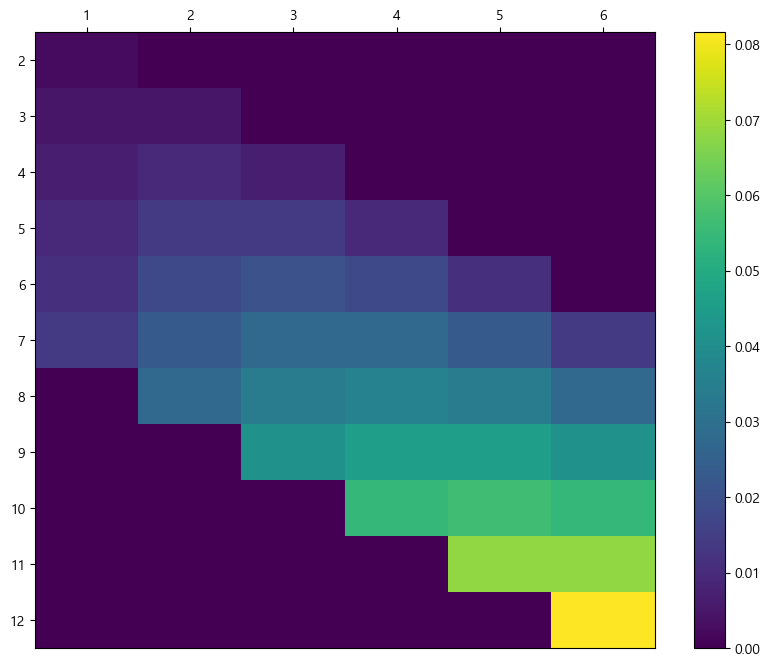

In [36]:
#확률분포 히트맵
prob = np.array([[f_XY(x_i, y_j) for y_j in y_set]
                 for x_i in x_set])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

c = ax.pcolor(prob)
ax.set_xticks(np.arange(prob.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(prob.shape[0]) + 0.5, minor=False)
ax.set_xticklabels(np.arange(1, 7), minor=False)
ax.set_yticklabels(np.arange(2, 13), minor=False)
# y축을 내림차순의 숫자가 되게 하여, 위 아래를 역전시킨다
ax.invert_yaxis()
# x축의 눈금을 그래프 위쪽에 표시
ax.xaxis.tick_top()
fig.colorbar(c, ax=ax)
plt.show()

## 연습문제

#### - csv 파일 가져와서 확률 계산 -> 히트맵까지 해보기

In [37]:
import pandas as pd

In [39]:
df = pd.read_csv('../통계분석2/받은 파일/data/card_usage_simple.csv')
df

,day_type,amount_band
0,weekday,mid
1,weekend,low
2,weekday,low
3,weekday,low
4,weekday,low
...,...,...
9995,weekday,mid
9996,weekday,low
9997,weekend,mid
9998,weekday,low


In [55]:
주중 = df[df['day_type'] == 'weekday']

주중_low = 주중[주중['amount_band'] == 'low'].value_counts()
주중_mid = 주중[주중['amount_band'] == 'mid'].value_counts()
주중_high = 주중[주중['amount_band'] == 'high'].value_counts()

print(주중_low)
print(주중_mid)
print(주중_high)
print(주중.count())

day_type  amount_band
weekday   low            4300
Name: count, dtype: int64
day_type  amount_band
weekday   mid            2014
Name: count, dtype: int64
day_type  amount_band
weekday   high           714
Name: count, dtype: int64
day_type       7028
amount_band    7028
dtype: int64


In [56]:
주말 = df[df['day_type'] == 'weekend']

주말_low = 주말[주말['amount_band'] == 'low'].value_counts()
주말_mid = 주말[주말['amount_band'] == 'mid'].value_counts()
주말_high = 주말[주말['amount_band'] == 'high'].value_counts()

print(주말_low)
print(주말_mid)
print(주말_high)
print(주말.count())

day_type  amount_band
weekend   low            1207
Name: count, dtype: int64
day_type  amount_band
weekend   mid            1022
Name: count, dtype: int64
day_type  amount_band
weekend   high           743
Name: count, dtype: int64
day_type       2972
amount_band    2972
dtype: int64


In [ ]:
#확률분포는 (해당 구간의 건수 / 전체 건수)로 계산
x_set = list(df['amount_band'].unique())
y_set = list(df['day_type'].unique())
N = len(df)

In [100]:
def f_XY(x, y):
    """
    x: amount_band ('low', 'mid', 'high')
    y: day_type ('weekday', 'weekend')
    결과: P(X=x, Y=y) = (해당 조건의 데이터 건수) / (전체 건수)
    """
    # 데이터프레임에서 x와 y 조건을 동시에 만족하는 행의 개수를 셉니다.
    condition = (df['amount_band'] == x) & (df['day_type'] == y)
    count = len(df[condition])
    
    return count / N

XY = [x_set, y_set, f_XY]

prob_table = [[f_XY(x, y) for x in x_set] for y in y_set]
print(prob_table)

[[0.2014, 0.43, 0.0714], [0.1022, 0.1207, 0.0743]]


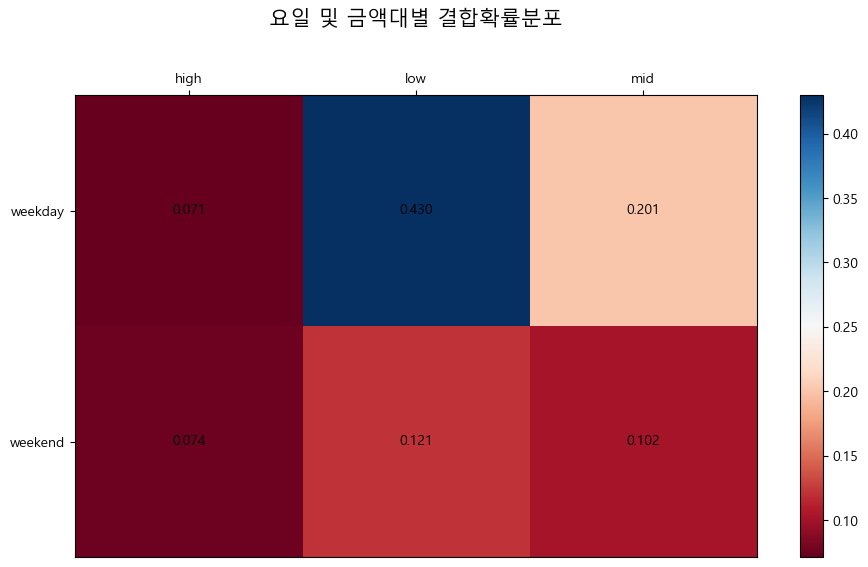

In [114]:
prob_array = np.array(prob_table)

fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(111)

c = ax.pcolor(prob_array, cmap='RdBu')

# 축 설정
ax.set_xticks(np.arange(prob_array.shape[1]) + 0.5, minor=False)
ax.set_xticklabels(x_set, minor=False) # 숫자가 아닌 x_set ('low' 등) 사용

ax.set_yticks(np.arange(prob_array.shape[0]) + 0.5, minor=False)
ax.set_yticklabels(y_set, minor=False) # 숫자가 아닌 y_set ('weekday' 등) 사용

ax.invert_yaxis()
ax.invert_xaxis()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 

# 각 칸에 확률 수치 써넣기
for y in range(prob_array.shape[0]):
    for x in range(prob_array.shape[1]):
        plt.text(x + 0.5, y + 0.5, f'{prob_array[y, x]:.3f}',
                 horizontalalignment='center',
                 verticalalignment='center',
                 color='black')

# 컬러바 및 레이블 추가
fig.colorbar(c, ax=ax)
plt.title('요일 및 금액대별 결합확률분포', pad=50, fontsize=15)

plt.show()